# Exercise 5 — Neural Networks

In this exercise, you will understand how a neural network learns by:

* combining inputs with weights
* applying activation functions
* training over epochs
* evaluating performance

## Part A — From Neuron to Prediction

A neuron receives inputs, combines them, and produces an output. `inputs → weighted sum → activation → output`

Mathematically `z = w1*x1 + w2*x2 + b`

Then `output = activation(z)`

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [54]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1 = 2
x2 = 3

w1 = 0.8
w2 = -2
b = 3

z = w1*x1 + w2*x2 + b
output = sigmoid(z)

print("z =", z)
print("output =", output)

z = -1.4000000000000004
output = 0.1978161114414182


### Questions

1. What happens if you change w1? - If w1 increases then output increases and go close to 1, if w1 decreases then output decreases, and go close to 0.
2. What happens if you change w2? - If w2 increases then output increases and go close to 1, if w2 decreases then output decreases, and go close to 0.
3. What happens if you change b? - Output changes the same way as when w1 and w2 are changed.
4. Why do we need an activation function?
    - Without an activation function, neural networks are just a series of linear transformations, no matter how many layers there are it will become just a single linear function.
    - Activation gives us non-linearity which allows the model to learn dataset of high complexity, those that can't be seperated by linear or simple polynomial curves.

## Part B — Activation Functions

In [55]:
x = np.linspace(-5, 5, 200)

print("mean:", np.mean(x))
print("std:", np.std(x))
print("variance:", np.var(x))
print("min:", np.min(x))
print("max:", np.max(x))
print("median:", np.median(x))
print("sum:", np.sum(x))

mean: 1.4210854715202004e-16
std: 2.901221368171633
variance: 8.41708542713568
min: -5.0
max: 5.0
median: 4.440892098500626e-16
sum: 2.842170943040401e-14


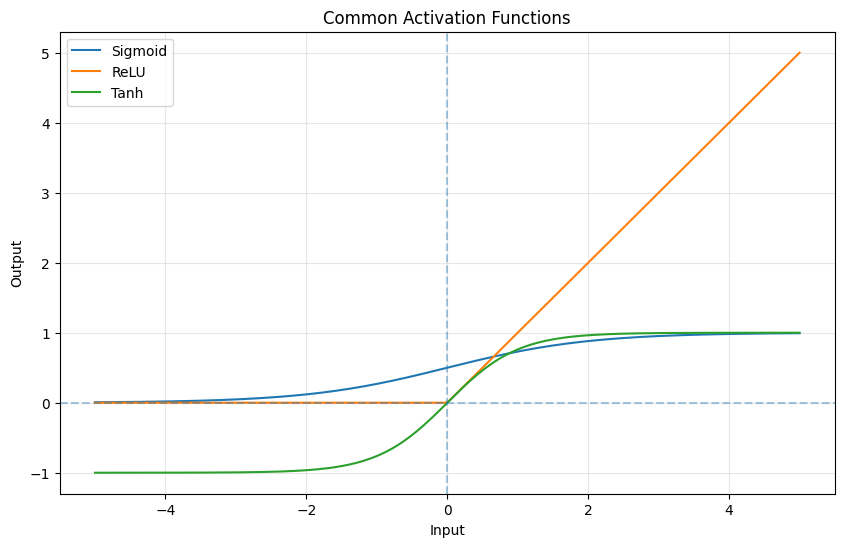

In [56]:
sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, tanh_y, label="Tanh")

plt.axhline(0, linestyle="--", alpha=0.4)
plt.axvline(0, linestyle="--", alpha=0.4)

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Questions

1. Which activation outputs values between 0 and 1? - Sigmoid function
2. Which activation keeps positive values unchanged? - ReLU
3. Which activation outputs values between -1 and 1? - Tanh
4. Which activation would you use for binary classification? - Sigmoid function, because values are between 0 and 1

## Part C — Build a Small Neural Network

We will train a neural network to classify two groups of points.

### Step 1 — Create a Dataset

In [75]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=400,
    noise=0.3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train[:10]

array([[ 0.51719897,  0.96089292],
       [ 2.2760827 , -0.14161133],
       [ 1.80878652,  0.18658868],
       [ 0.40208621, -0.29010777],
       [ 1.1338868 ,  0.3408727 ],
       [ 0.70835034,  0.0394816 ],
       [ 0.33614555,  0.79615312],
       [-0.9769418 ,  0.45074655],
       [-0.66901086,  0.68741144],
       [ 0.06935491,  1.34176093]])

In [76]:
y_train[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Look at the data.
* What type of ML problem is this? - It's a binary classification problem because output is either 0 or 1
* How many features does the dataset have?

In [77]:
print(f"Number of samples: {X.shape[0]}, number of features: {X.shape[1]}")

Number of samples: 400, number of features: 2


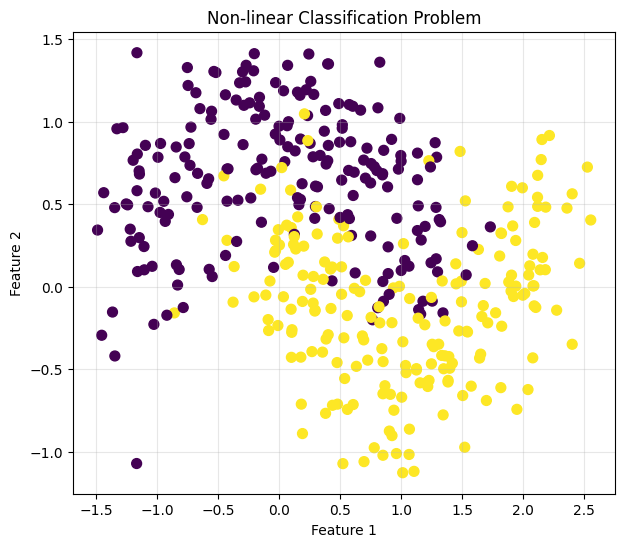

In [78]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Non-linear Classification Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

### Why this dataset?

This dataset cannot be easily separated by a straight line.

A neural network can learn a non-linear decision boundary.

Other simulated datasets [here](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

## Part D — Train a Neural Network

Check the documentation for [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [79]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8


## Part E — Visualize the Decision Boundary

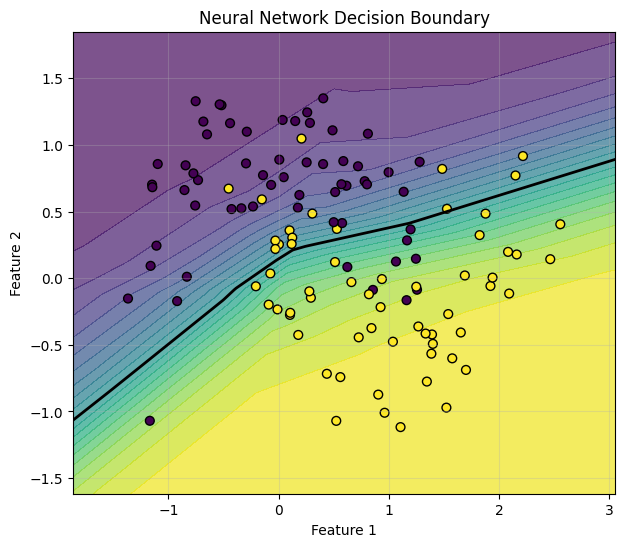

In [80]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # probability background
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)

    # decision boundary: probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    # data points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")

    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### Questions

1. Is the decision boundary linear or non-linear? - It's a non-linear because it's not a straight line
2. Does the model separate the two classes well? - In this case it does quite well, but mistakes are still made (20% of the time)
3. Where does it make mistakes? - Around (0, 0.3) where overlaps happens, some yellow points stay closer to a group of purple points and the model wrongly classify them. Same goes for a group of purple points around (1.2, 0,25).
4. Why is a neural network useful here? - It allows us to use a non-linear relationship to classify the 2 groups.

## Part F — Training Over Epochs

Neural networks train over multiple epochs.

One epoch means: `one full pass through the training dataset`

### Train with Different Numbers of Epochs

In [82]:
epochs = [10, 50, 200, 1000, 1500]

for epoch in epochs:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        max_iter=epoch,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Epochs: {epoch} | Accuracy: {acc:.3f}")

Epochs: 10 | Accuracy: 0.458
Epochs: 50 | Accuracy: 0.675
Epochs: 200 | Accuracy: 0.808
Epochs: 1000 | Accuracy: 0.800
Epochs: 1500 | Accuracy: 0.800


/home/krazykun2/Desktop/ict_courses/Machine Learning and Data Mining/ml-course/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/krazykun2/Desktop/ict_courses/Machine Learning and Data Mining/ml-course/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/krazykun2/Desktop/ict_courses/Machine Learning and Data Mining/ml-course/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Part G — Compare Different Network Sizes

In [83]:
architectures = [
    (2,),
    (10,),
    (50,),
    (50, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Architecture: {arch} | Accuracy: {acc:.3f}")

Architecture: (2,) | Accuracy: 0.825
Architecture: (10,) | Accuracy: 0.800
Architecture: (50,) | Accuracy: 0.892
Architecture: (50, 50) | Accuracy: 0.908


### Questions

1. `architectures = [(2,), (10,), (50,), (50, 50)]`
What do these numbers mean? 10, (50, 50)?
    - It means the number of layer and neurons in each of the layer
        - `(2,)`: 1 layer, 2 neurons
        - `(10, )`: 1 layer, 2 neurons
        - `(50, )`: 1 layer, 50 neurons
        - `(50, 50)`: 2 layer, 50 neurons for each
3. What happens when the network has very few neurons? - In this case it makes mistakes about 20% of the time, so it is not enough to learn the curve pattern.
4. What happens when the network has many neurons? - The accuracy increases up to 90%
5. Which model seems best? - The `(50, 50)` model
6. Can a neural network overfit? - Yes, it happens when the network is too large and is trained for too long so it starts memorizing data. We need to verify with train, dev, and test data.

## Part H — Confusion Matrix

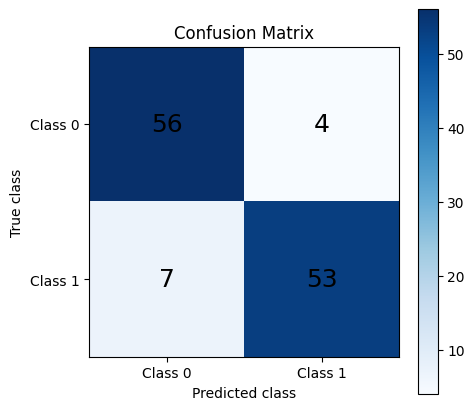

In [85]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Questions

Try and respond to these questions in a summarized manner.
1. What does a hidden layer do?
2. Why do we need activation functions?
3. What is the role of epochs?
4. What is the role of weights?
5. What happens if the network is too small?
6. What happens if the network is too large?

## For more complex coded neural networks, check:

* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html